# 04 — Mô hình Lee-Carter (baseline)

Trước khi chạy notebook này, cần fit mô hình bằng R (chỉ cần chạy một lần, hoặc
lại mỗi khi `data/processed/Dxt_total.csv`/`Ext_total.csv` thay đổi):

```bash
Rscript R/02a_fit_lc.R
```

Script này fit LC trên series `total` và ghi tham số ra
`data/processed/params_lc_*.csv` + residuals — notebook 04 chỉ đọc và
trực quan hoá phần LC (`params_lc_age.csv`, `params_lc_kt.csv`,
`residuals_lc.csv`). Trình bày: ax, bx, kt; kiểm tra giả định random-walk-with-drift
của kt; residual heatmap; diễn giải tham số cho dữ liệu Việt Nam.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import numpy as np
import pandas as pd
from src.config import DATA_PROCESSED, load_params

cfg = load_params()

params_age = pd.read_csv(DATA_PROCESSED / "params_lc_age.csv")
params_kt = pd.read_csv(DATA_PROCESSED / "params_lc_kt.csv")
kt = params_kt.set_index("year")["kt"]

residuals_lc = pd.read_csv(DATA_PROCESSED / "residuals_lc.csv", index_col=0)
residuals_lc.columns = residuals_lc.columns.astype(int)
residuals_lc.index = residuals_lc.index.astype(int)

params_age.shape, kt.shape, residuals_lc.shape

((91, 3), (31,), (91, 31))

## Tham số ax, bx, kt

Mô hình Lee-Carter: $\log m_{x,t} = a_x + b_x k_t$, với ràng buộc chuẩn hoá
$\sum_x b_x = 1$, $\sum_t k_t = 0$ (StMoMo dùng ràng buộc này mặc định).

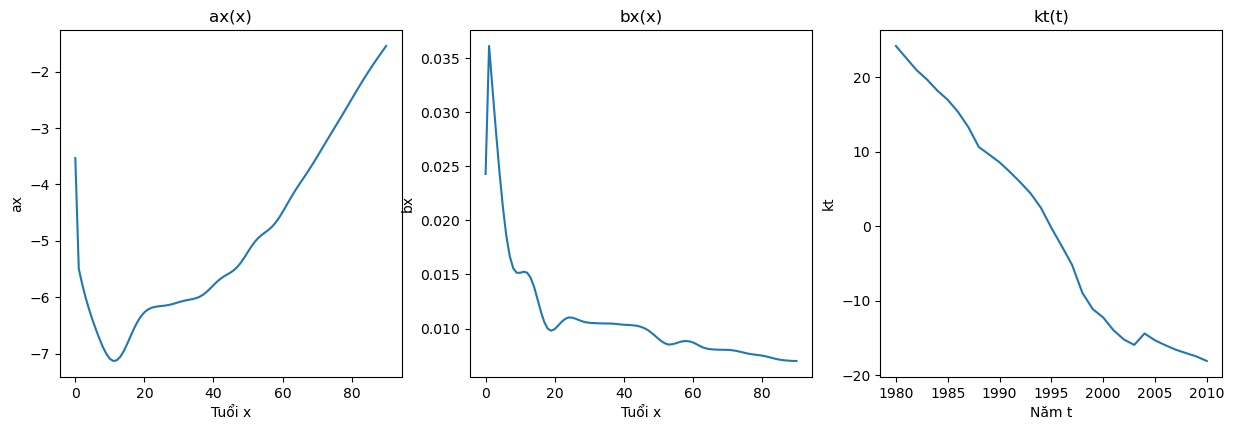

In [3]:
from src.visualization.plots import plot_lc_params

plot_lc_params(params_age, kt, name="lc_params_total")

**Nhận xét:**

- **ax(x)** tái hiện đúng hình "checkmark" đã thấy ở log mx thô (notebook 02):
  thấp nhất ở tuổi 11 (ax ≈ −7.13, đáy tử vong tuổi thiếu niên), cao nhất ở
  tuổi 90 (ax ≈ −1.55). Hợp lý vì ax chính là log mx trung bình theo thời gian
  ở từng tuổi, tính trên cửa sổ fit 1980-2010.
- **bx(x)** đo mức độ mỗi tuổi phản ứng với xu hướng chung kt — **cao nhất ở
  đúng tuổi 1** (bx ≈ 0.0361, gấp ~3.3 lần mức trung bình 1/91≈0.011), rồi
  giảm dần và thấp nhất ở tuổi 90 (bx ≈ 0.007). Tuổi 1 nhạy nhất với kt nghĩa
  là mx tuổi 1 biến động (cải thiện) nhanh nhất theo thời gian trong toàn bộ
  dải tuổi — đáng chú ý vì đây đúng là tuổi từng được flag có ngoại lệ tỷ số
  nam/nữ ở notebook 02; bx cao bất thường ở đây có thể một phần phản ánh cùng
  nguồn artifact ước lượng của UN cho tử vong trẻ em, chứ không hẳn thuần tuý
  là tín hiệu cải thiện y tế.
- **kt(t)** giảm gần như tuyến tính từ **24.22 (1980) xuống −18.09 (2010)**,
  độ dốc trung bình ≈ **−1.57/năm** — vì bx > 0 với mọi tuổi, kt giảm đồng
  nghĩa mx giảm ở mọi tuổi cùng chiều, đúng với xu hướng cải thiện tử vong
  chung đã thấy xuyên suốt notebook 02. Lưu ý: cửa sổ fit hiện tại (1980-2010,
  31 năm) hẹp hơn nhiều so với toàn bộ dữ liệu thu thập được (1955-2023) - loại
  giai đoạn 1955-1979 dựa trên bằng chứng điểm gãy cấu trúc năm 1974 đã tìm
  thấy ở notebook 02 (`fitting.years` trong `config/params.yaml`).

## Kiểm tra giả định random-walk-with-drift cho kt

`config/params.yaml` chọn RWD (`forecast.kt_model: "rwd"`) để dự báo kt ở
notebook 07 — RWD hợp lý khi kt là bước ngẫu nhiên (chuỗi mức, non-stationary)
còn sai phân bậc 1 của kt là stationary. Kiểm tra bằng ADF test (Augmented
Dickey-Fuller) trên cả kt gốc và diff(kt).

In [4]:
from statsmodels.tsa.stattools import adfuller

dkt = kt.diff().dropna()
stat_level, p_level, *_ = adfuller(kt)
stat_diff, p_diff, *_ = adfuller(dkt)

pd.DataFrame({
    "chuỗi": ["kt (gốc)", "diff(kt)"],
    "ADF statistic": [round(stat_level, 3), round(stat_diff, 3)],
    "p-value": [round(p_level, 4), round(p_diff, 6)],
    "drift trung bình diff": [np.nan, round(dkt.mean(), 3)],
})

,chuỗi,ADF statistic,p-value,drift trung bình diff
0,kt (gốc),-1.432,0.566700,NaN
1,diff(kt),-2.610,0.090909,-1.41


**Nhận xét:** kt gốc **không bác bỏ** giả thuyết có unit root (p ≈ 0.57 — không
stationary, đúng như kỳ vọng của một random walk), nhưng diff(kt) chỉ bác bỏ
giả thuyết đó ở mức ý nghĩa **biên** (p ≈ 0.09 — không đạt ngưỡng 5% thông
thường), yếu hơn hẳn so với kỳ vọng ban đầu. Nguyên nhân: cửa sổ fit hiện tại
chỉ có 31 năm (1980-2010) → diff(kt) chỉ còn 30 quan sát, ít hơn nhiều so với
68 sai phân nếu tính trên toàn bộ 1955-2023 - kiểm định ADF mất power thống kê
đáng kể khi cỡ mẫu nhỏ đi. Drift trung bình vẫn âm rõ rệt (≈ −1.41/năm, khớp
hướng với độ dốc tuyến tính ước lượng ở trên).

Vì vậy, bằng chứng **chính** để chọn random-walk-with-drift cho kt trong
`config/params.yaml` nên dựa vào kiểm định ADF trên chỉ số $\bar m_t$ (trung
bình log mx theo tuổi 0-90) tính trên toàn bộ 1955-2023 ở notebook 02 - kiểm
định đó có 68 sai phân (nhiều hơn hẳn 30 sai phân ở đây) nên có power cao hơn,
và cho kết quả rõ ràng hơn (p ≈ 0.0002 cho diff, xem notebook 02). Kết quả ADF
trực tiếp trên kt ở đây nên được xem là bằng chứng **bổ sung, yếu hơn**, không
phải bằng chứng chính - đây cũng là một hạn chế cần nêu trong luận văn: cửa sổ
fit 30 năm là tương đối ngắn để kiểm định vững chắc tính chất chuỗi thời gian
của kt.

## Residual heatmap — kiểm tra hiệu ứng thế hệ còn sót lại

Deviance residual thật của mô hình LC đã fit (khác với phần dư "naive" tuổi+năm
dùng để thăm dò ở notebook 02) — nếu còn vệt chéo hệ thống theo cohort, đó là
bằng chứng LC (không có cấu phần cohort) bỏ sót cấu trúc thật trong dữ liệu,
lý do chính để chuyển sang Renshaw-Haberman ở notebook 05.

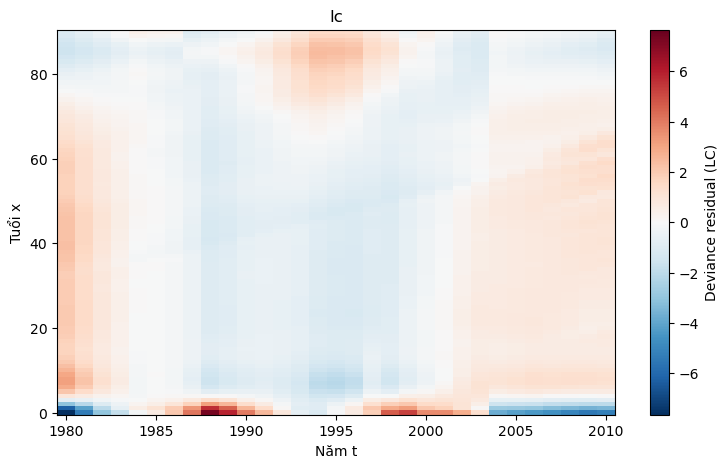

In [5]:
from src.visualization.plots import plot_residual_heatmap

plot_residual_heatmap(residuals_lc, model="lc", ylabel="Deviance residual (LC)")

In [6]:
from src.evaluation.cohort import cohort_mean_residual

# min_obs=40 không còn phù hợp: cửa sổ fit chỉ còn 1980-2010 (31 năm), nên số
# quan sát tối đa mỗi cohort là 31 - min_obs=40 luôn cho ra rỗng. Dùng min_obs=20
# (~2/3 số năm có thể có) để loại cohort ở rìa mà vẫn giữ đủ dữ liệu để tính.
cohort_resid_lc = cohort_mean_residual(residuals_lc, min_obs=20)
print("Khoảng biến thiên residual trung bình theo cohort (n>=20):",
      round(cohort_resid_lc.min(), 3), "->", round(cohort_resid_lc.max(), 3))
cohort_resid_lc.sort_values(ascending=False).head(5).round(3).to_frame("mean_residual")

Khoảng biến thiên residual trung bình theo cohort (n>=20): -0.593 -> 0.527


,mean_residual
1910,0.527
1911,0.514
1909,0.498
1912,0.457
1913,0.373


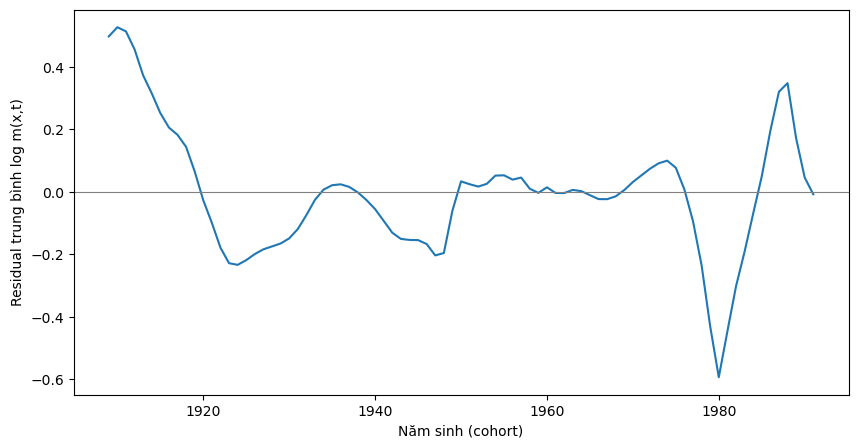

In [7]:
from src.visualization.plots import plot_cohort_mean_residual

plot_cohort_mean_residual(cohort_resid_lc, name="lc_cohort_mean_residual")

**Nhận xét:**

- Deviance residual trung bình theo cohort (n≥20 ô tuổi-năm) dao động từ
  **−0.59 (cohort 1980)** đến **+0.53 (cohort 1910)**. Khác với lần chạy
  trước (cửa sổ 1955-2023, đỉnh dương gọn ở 1980-1984): với cửa sổ hẹp hơn
  (1980-2010, 31 năm), phần lớn cohort cực trị nằm ngay tại hoặc gần **biên**
  của cửa sổ quan sát - cohort 1980 chỉ quan sát được ở tuổi 0 (năm đầu cửa
  sổ), cohort 1910 chỉ quan sát được ở tuổi 70-90 (chỉ tồn tại ở phần già của
  cửa sổ). Đây là dấu hiệu của vấn đề nhận dạng tuổi-năm-thế hệ (age-period-
  cohort identification problem) khi cửa sổ thời gian ngắn so với dải tuổi
  fit, chứ không phải một mô thức cohort có cấu trúc rõ ràng như đỉnh gọn
  1980-1984 quan sát được ở lần chạy trước.
- **Không nên dùng kết quả này để kết luận về hình dạng thật của hiệu ứng thế
  hệ.** So với "gò" ở notebook 02 (đỉnh dương ở cohort 1950-1954, tính trên
  toàn bộ 1955-2023 bằng phân rã naive, giả định ngầm $b_x=1$): hai phép tính
  vừa khác phương pháp (naive vs. deviance residual thật của LC) vừa khác hẳn
  cửa sổ quan sát (69 năm vs. 31 năm), nên không so sánh trực tiếp được nữa.
  Kết luận chắc chắn về hiệu ứng thế hệ tại Việt Nam cần đợi ước lượng $\gamma_c$
  chính thức của Renshaw-Haberman (notebook 05) - và ngay cả khi đó, cửa sổ fit
  30 năm vẫn là một hạn chế cần nêu rõ khi diễn giải $\gamma_c$ ở các cohort gần
  biên (đầu 1980s và cuối 2000s).